## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Chargement du Dataset

In [16]:
# Chargement du dataset brut
df_raw = pd.read_csv('../Data/RTA Dataset.csv')

# -----------------------------------------------------------
# Shuffle + échantillonnage à 3000 lignes (consigne du prof)
# -----------------------------------------------------------
df = df_raw.sample(frac=1, random_state=42).reset_index(drop=True)
df = df.head(3000)

print(f'Taille après shuffle + sélection : {df.shape}')
df.head()

Taille après shuffle + sélection : (3000, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,14:27:00,Friday,Over 51,Male,Junior high school,Employee,Above 10yr,NaN,Owner,2-5yrs,...,U-Turn,na,na,na,na,Driver,Normal,Not a Pedestrian,Changing lane to the left,Slight Injury
1,16:00:00,Sunday,Under 18,Male,Junior high school,Employee,Below 1yr,Automobile,Owner,NaN,...,Other,na,na,na,na,NaN,NaN,Not a Pedestrian,Driving carelessly,Slight Injury
2,16:56:00,Wednesday,18-30,Male,NaN,NaN,NaN,NaN,NaN,NaN,...,Getting off,Driver or rider,Male,18-30,3,Driver,Normal,Not a Pedestrian,No distancing,Serious Injury
3,15:48:00,Tuesday,31-50,Male,Junior high school,Employee,Below 1yr,Public (12 seats),Owner,NaN,...,Going straight,Driver or rider,Male,18-30,3,Self-employed,Normal,Not a Pedestrian,Moving Backward,Slight Injury
4,12:48:00,Friday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,Unknown,...,Going straight,Passenger,Female,31-50,3,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury


## 2. Informations Générales sur le Dataset

In [6]:
# Aperçu général
print('=== SHAPE ===')
print(f'Lignes : {df.shape[0]}  |  Colonnes : {df.shape[1]}')

print('\n=== TYPES DE VARIABLES ===')
print(df.dtypes)

print('\n=== INFORMATIONS GÉNÉRALES ===')
df.info()

=== SHAPE ===
Lignes : 3000  |  Colonnes : 32

=== TYPES DE VARIABLES ===
Time                           object
Day_of_week                    object
Age_band_of_driver             object
Sex_of_driver                  object
Educational_level              object
Vehicle_driver_relation        object
Driving_experience             object
Type_of_vehicle                object
Owner_of_vehicle               object
Service_year_of_vehicle        object
Defect_of_vehicle              object
Area_accident_occured          object
Lanes_or_Medians               object
Road_allignment                object
Types_of_Junction              object
Road_surface_type              object
Road_surface_conditions        object
Light_conditions               object
Weather_conditions             object
Type_of_collision              object
Number_of_vehicles_involved     int64
Number_of_casualties            int64
Vehicle_movement               object
Casualty_class                 object
Sex_of_casualt

## 3. Statistiques Descriptives

In [7]:
# Variables numériques
print('=== VARIABLES NUMÉRIQUES ===')
df.describe()

=== VARIABLES NUMÉRIQUES ===


,Number_of_vehicles_involved,Number_of_casualties
count,3000.000000,3000.000000
mean,2.034667,1.576000
std,0.682852,1.054796
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [8]:
# Variables catégorielles
print('=== VARIABLES CATÉGORIELLES ===')
df.describe(include='object')

=== VARIABLES CATÉGORIELLES ===


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
count,3000,3000,3000,3000,2820,2857,2788,2763,2888,2038,...,2912,3000,3000,3000,3000,2212,2357,3000,3000,3000
unique,783,7,5,3,7,4,7,17,4,6,...,13,4,3,6,4,7,5,9,20,3
top,17:10:00,Friday,18-30,Male,Junior high school,Employee,5-10yr,Automobile,Owner,Unknown,...,Going straight,Driver or rider,Male,na,3,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
freq,29,506,1058,2784,1855,2350,783,787,2538,718,...,1986,1191,1272,1087,1712,1400,2338,2783,572,2510



## 4. Analyse des Valeurs Manquantes

Colonnes avec valeurs manquantes : 16
                         Missing Count  Missing %
Defect_of_vehicle                 1039      34.63
Service_year_of_vehicle            962      32.07
Work_of_casuality                  788      26.27
Fitness_of_casuality               643      21.43
Type_of_vehicle                    237       7.90
Types_of_Junction                  221       7.37
Driving_experience                 212       7.07
Educational_level                  180       6.00
Vehicle_driver_relation            143       4.77
Owner_of_vehicle                   112       3.73
Lanes_or_Medians                    96       3.20
Vehicle_movement                    88       2.93
Area_accident_occured               56       1.87
Road_surface_type                   50       1.67
Type_of_collision                   35       1.17
Road_allignment                     31       1.03


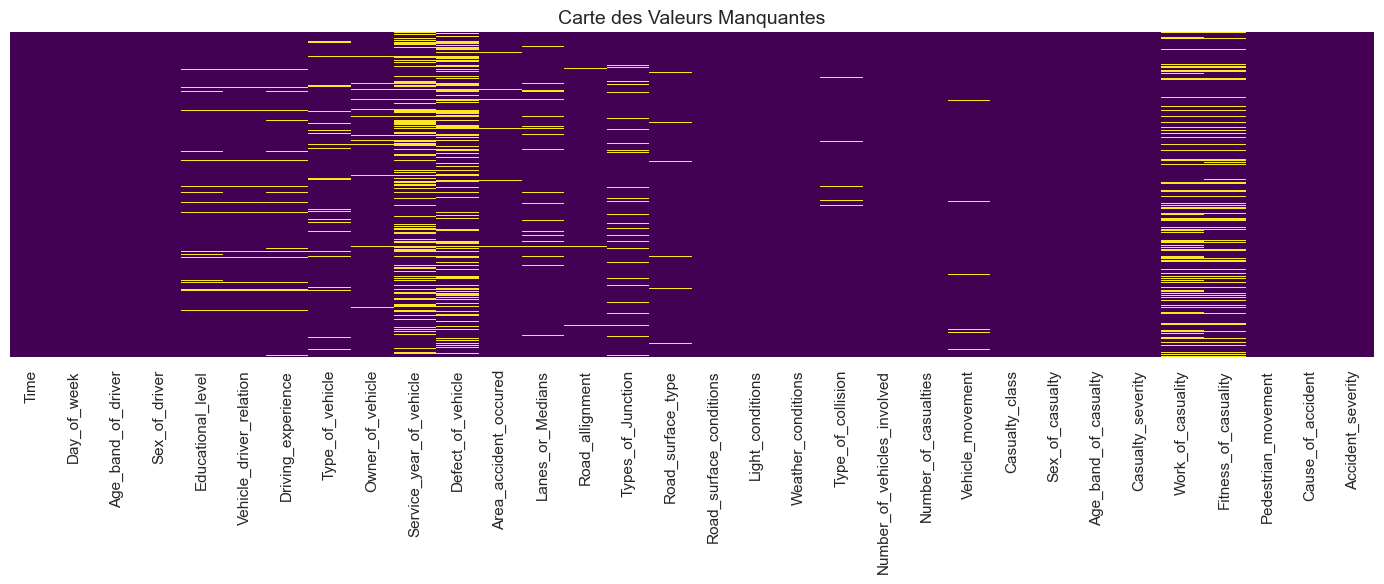

In [9]:
# Calcul du taux de valeurs manquantes par colonne
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Colonnes avec valeurs manquantes : {len(missing_df)}')
print(missing_df)

# Heatmap des valeurs manquantes
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Carte des Valeurs Manquantes', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Distribution de la Variable Cible

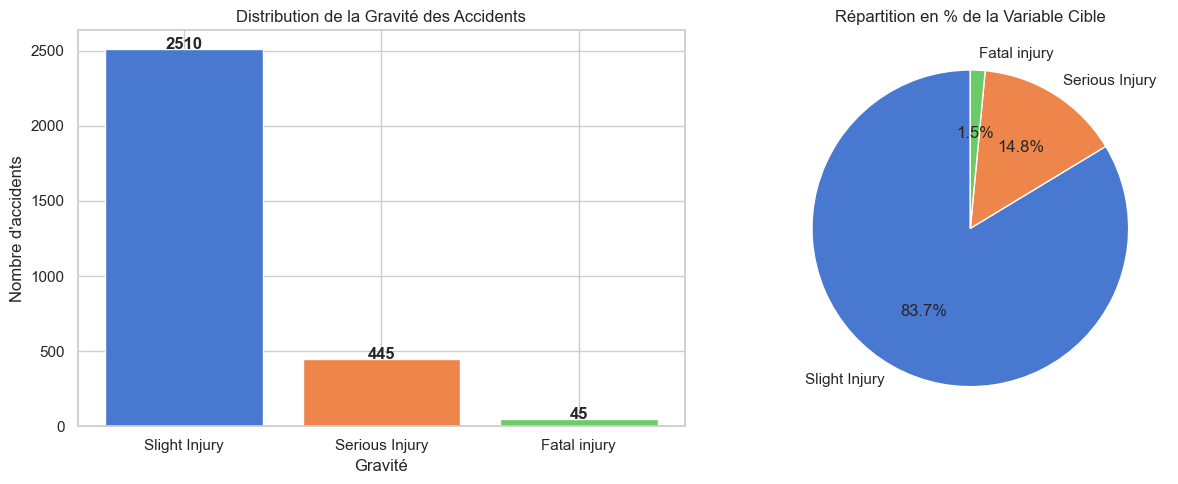


⚠️  Déséquilibre des classes détecté — à gérer dans la phase de modélisation (SMOTE / class_weight).


In [10]:
target = 'Accident_severity'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barplot
value_counts = df[target].value_counts()
axes[0].bar(value_counts.index, value_counts.values, color=sns.color_palette('muted'))
axes[0].set_title('Distribution de la Gravité des Accidents')
axes[0].set_xlabel('Gravité')
axes[0].set_ylabel('Nombre d\'accidents')
for i, v in enumerate(value_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Camembert
axes[1].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted'), startangle=90)
axes[1].set_title('Répartition en % de la Variable Cible')

plt.tight_layout()
plt.show()

print('\n⚠️  Déséquilibre des classes détecté — à gérer dans la phase de modélisation (SMOTE / class_weight).')

## 6. Analyse des Variables Catégorielles

In [11]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
if target in cat_cols:
    cat_cols.remove(target)

print(f'Variables catégorielles : {len(cat_cols)}')
print(cat_cols)

Variables catégorielles : 29
['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident']


In [12]:
# Affichage du nombre de modalités par variable catégorielle
for col in cat_cols:
    print(f'{col:40s} → {df[col].nunique()} modalités')

Time                                     → 783 modalités
Day_of_week                              → 7 modalités
Age_band_of_driver                       → 5 modalités
Sex_of_driver                            → 3 modalités
Educational_level                        → 7 modalités
Vehicle_driver_relation                  → 4 modalités
Driving_experience                       → 7 modalités
Type_of_vehicle                          → 17 modalités
Owner_of_vehicle                         → 4 modalités
Service_year_of_vehicle                  → 6 modalités
Defect_of_vehicle                        → 3 modalités
Area_accident_occured                    → 13 modalités
Lanes_or_Medians                         → 7 modalités
Road_allignment                          → 9 modalités
Types_of_Junction                        → 8 modalités
Road_surface_type                        → 5 modalités
Road_surface_conditions                  → 3 modalités
Light_conditions                         → 4 modalités
Weathe

## 7. Analyse des Variables Numériques

Variables numériques : ['Number_of_vehicles_involved', 'Number_of_casualties']


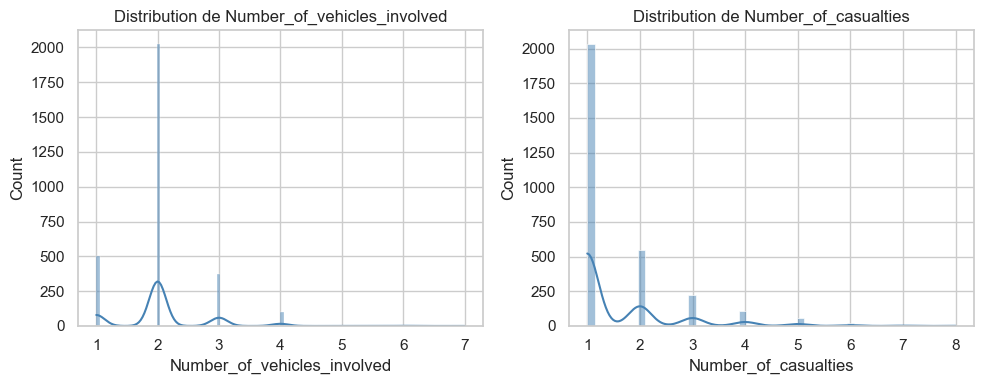

In [13]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print(f'Variables numériques : {num_cols}')

if num_cols:
    fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 4))
    if len(num_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, num_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue')
        ax.set_title(f'Distribution de {col}')
    plt.tight_layout()
    plt.show()
else:
    print('Pas de variables numériques continues dans ce dataset.')

## 8. Analyse Temporelle (Heure / Jour)

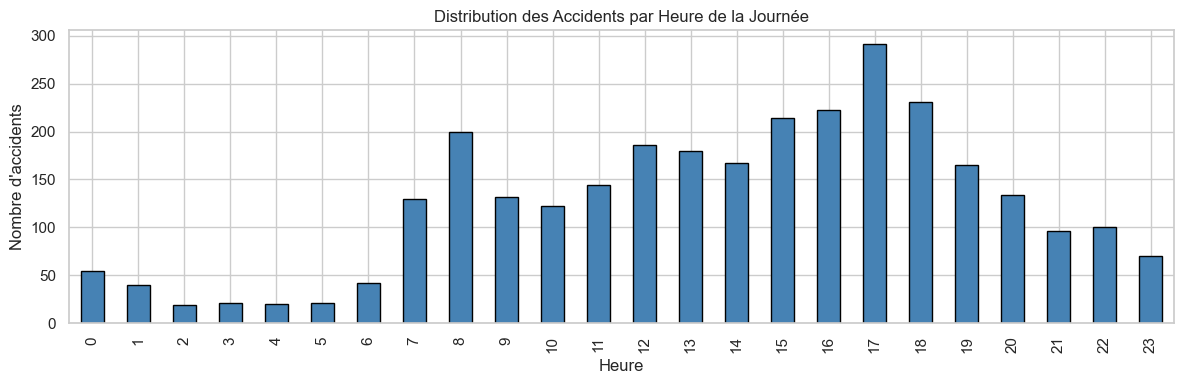

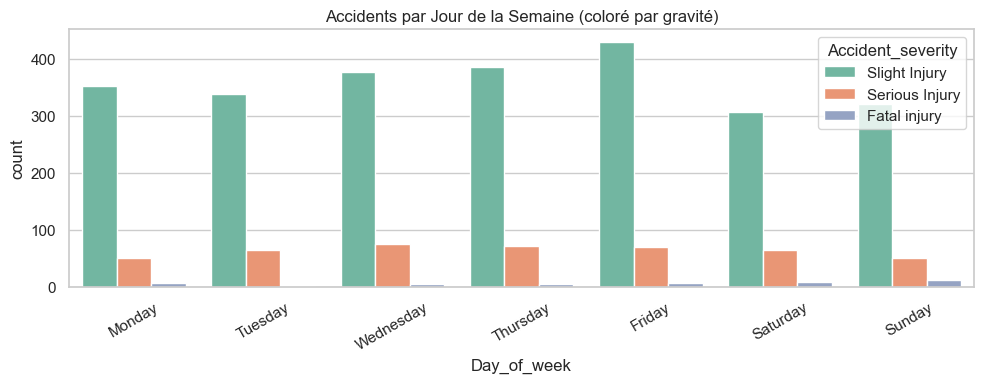

In [14]:
# Analyse par heure si la colonne Time existe
if 'Time' in df.columns:
    df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour

    plt.figure(figsize=(12, 4))
    df['Hour'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Distribution des Accidents par Heure de la Journée')
    plt.xlabel('Heure')
    plt.ylabel('Nombre d\'accidents')
    plt.tight_layout()
    plt.show()

# Analyse par jour
if 'Day_of_week' in df.columns:
    order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    order = [d for d in order if d in df['Day_of_week'].unique()]
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x='Day_of_week', order=order, hue='Accident_severity', palette='Set2')
    plt.title('Accidents par Jour de la Semaine (coloré par gravité)')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## 9. Matrice de Corrélation (variables numériques encodées)

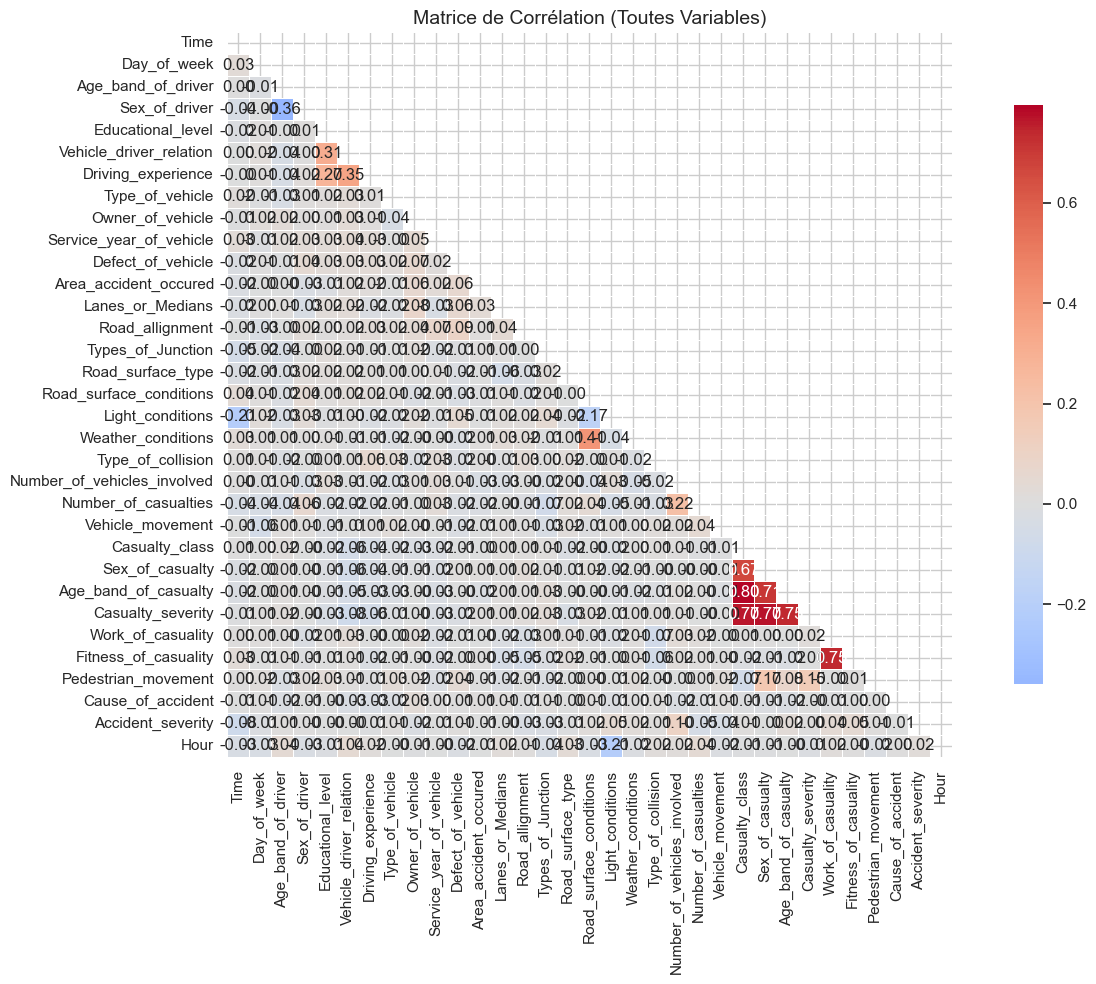

In [15]:
# Encodage ordinal temporaire pour la corrélation
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(14, 10))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matrice de Corrélation (Toutes Variables)', fontsize=14)
plt.tight_layout()
plt.show()